# EDA — NO2.csv
Score de Vivabilité · Concentrations NO₂ sur les tronçons du Périphérique parisien

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parents[0]
FILE = BASE_DIR / 'brute' / 'score_de_vivabilité' / 'NO2.csv'

df = pd.read_csv(FILE, sep=None, engine='python')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)
df['time'] = pd.to_datetime(df['time'], errors='coerce')
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

Shape : (3120, 9)
Colonnes : ['time', 'Chap-Bagn', 'Bagn-Berc', 'Berc-Ital', 'Ital-A6a', 'A6a-Sevr', 'Sevr-Aute', 'Aute-Mail', 'Mail-Chap']


,time,Chap-Bagn,Bagn-Berc,Berc-Ital,Ital-A6a,A6a-Sevr,Sevr-Aute,Aute-Mail,Mail-Chap
0,2026-01-01 00:00:00,87.0,86.0,91.0,71.0,75.0,77.0,87.0,94.0
1,2026-01-01 01:00:00,83.0,83.0,84.0,72.0,79.0,73.0,80.0,87.0
2,2026-01-01 02:00:00,79.0,77.0,77.0,67.0,68.0,61.0,69.0,78.0
3,2026-01-01 03:00:00,65.0,67.0,64.0,57.0,55.0,49.0,54.0,68.0
4,2026-01-01 04:00:00,65.0,70.0,63.0,49.0,49.0,45.0,55.0,65.0


## 2. Infos générales

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3120 entries, 0 to 3119
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   time       3120 non-null   datetime64[us]
 1   Chap-Bagn  3095 non-null   float64       
 2   Bagn-Berc  3095 non-null   float64       
 3   Berc-Ital  3095 non-null   float64       
 4   Ital-A6a   3095 non-null   float64       
 5   A6a-Sevr   3095 non-null   float64       
 6   Sevr-Aute  3095 non-null   float64       
 7   Aute-Mail  3095 non-null   float64       
 8   Mail-Chap  3095 non-null   float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 219.5 KB


In [4]:
df.describe(include='all')

,time,Chap-Bagn,Bagn-Berc,Berc-Ital,Ital-A6a,A6a-Sevr,Sevr-Aute,Aute-Mail,Mail-Chap
count,3120,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000
mean,2026-03-06 23:30:00,40.956704,47.257512,44.924394,36.441034,36.201939,36.554443,44.118578,41.861066
min,2026-01-01 00:00:00,7.000000,7.000000,7.000000,4.000000,3.000000,4.000000,5.000000,6.000000
25%,2026-02-02 11:45:00,29.000000,35.000000,32.000000,25.000000,25.000000,25.000000,32.000000,29.000000
50%,2026-03-06 23:30:00,38.000000,45.000000,42.000000,34.000000,34.000000,35.000000,43.000000,39.000000
75%,2026-04-08 11:15:00,50.000000,58.000000,55.000000,45.000000,44.000000,45.000000,54.000000,51.000000
max,2026-05-10 23:00:00,109.000000,114.000000,113.000000,119.000000,117.000000,112.000000,107.000000,124.000000
std,NaN,17.536260,18.203917,17.940380,16.197183,16.491294,15.900309,16.986034,17.748078


## 3. Valeurs manquantes — critique pour ce dataset

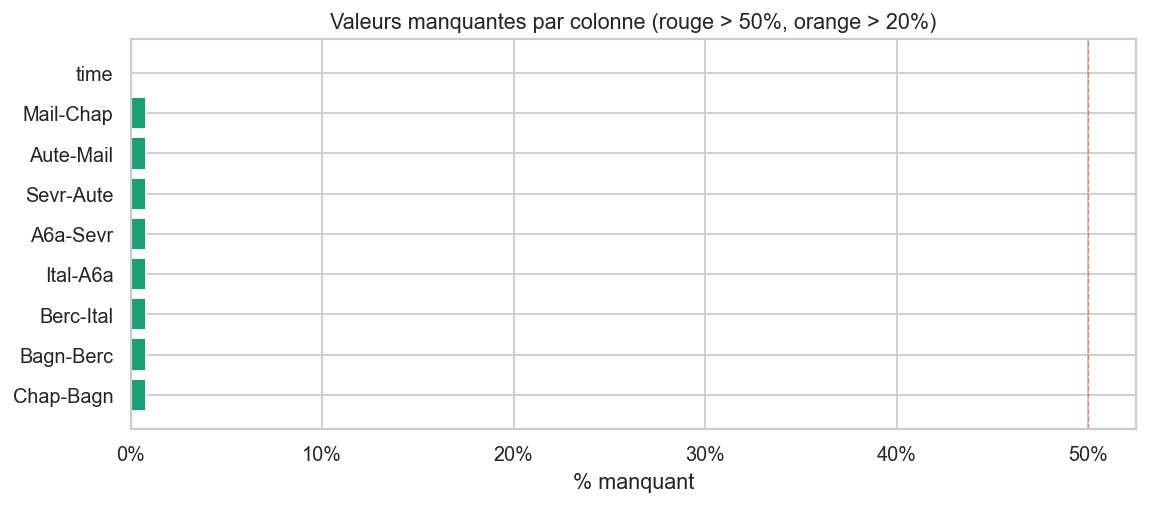

,% manquant
Chap-Bagn,0.801282
Bagn-Berc,0.801282
Berc-Ital,0.801282
Ital-A6a,0.801282
A6a-Sevr,0.801282
Sevr-Aute,0.801282
Aute-Mail,0.801282
Mail-Chap,0.801282
time,0.000000


In [5]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(3, len(df.columns) * 0.45)))
colors = ['#D85A30' if v > 50 else '#BA7517' if v > 20 else '#1D9E75' for v in missing.values]
ax.barh(missing.index, missing.values, color=colors)
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par colonne (rouge > 50%, orange > 20%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.axvline(50, color='#D85A30', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

display(missing.rename('% manquant').to_frame())

## 4. Doublons

In [6]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

Doublons : 0 (0.00%)


## 5. Couverture temporelle

In [7]:
print(f'Première mesure : {df["time"].min()}')
print(f'Dernière mesure : {df["time"].max()}')
print(f'Durée couverte  : {(df["time"].max() - df["time"].min()).days} jours')
print(f'Nb mesures      : {len(df):,}')
freq = df['time'].diff().dt.total_seconds().dropna().mode()
if not freq.empty:
    print(f'Fréquence mode  : {freq.values[0]/3600:.1f}h')

Première mesure : 2026-01-01 00:00:00
Dernière mesure : 2026-05-10 23:00:00
Durée couverte  : 129 jours
Nb mesures      : 3,120
Fréquence mode  : 1.0h


## 6. Distribution NO₂ par tronçon

/var/folders/qb/k892z_d577q8nhdfb8x4fnrh0000gn/T/ipykernel_13419/3325793370.py:11: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ben/Downloads/developpement_architecture_de_données/projet/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


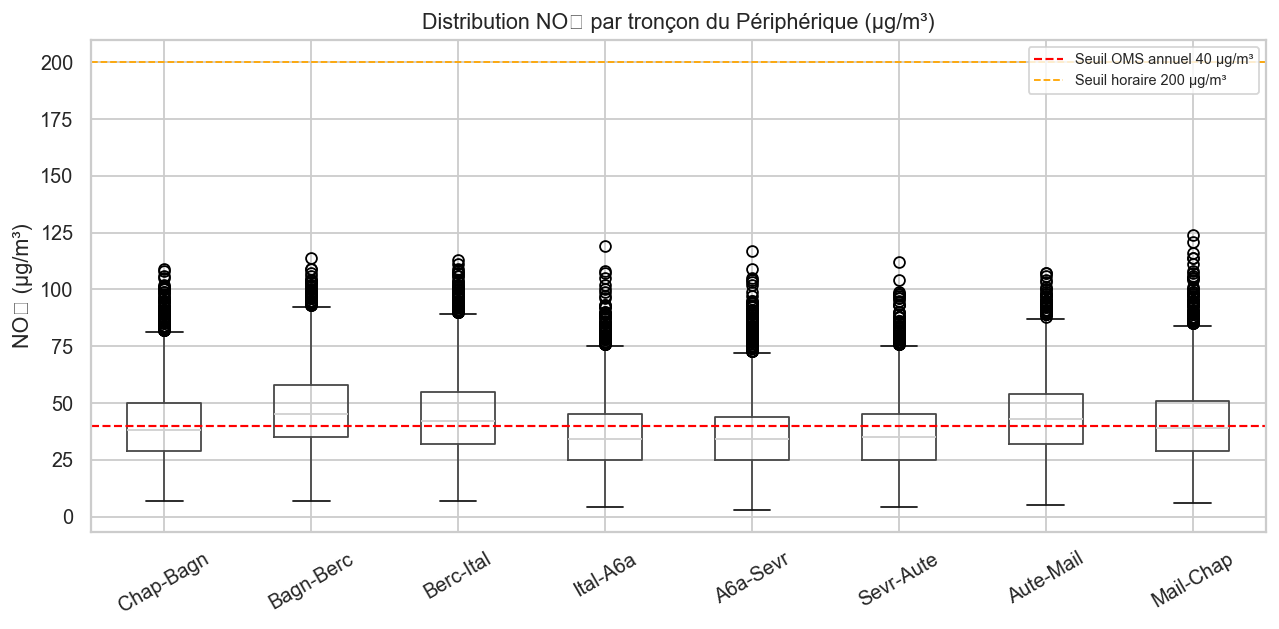

,count,mean,std,min,25%,50%,75%,max,> seuil OMS (%)
Chap-Bagn,3095.0,40.96,17.54,7.0,29.0,38.0,50.0,109.0,43.40
Bagn-Berc,3095.0,47.26,18.20,7.0,35.0,45.0,58.0,114.0,60.93
Berc-Ital,3095.0,44.92,17.94,7.0,32.0,42.0,55.0,113.0,54.78
Ital-A6a,3095.0,36.44,16.20,4.0,25.0,34.0,45.0,119.0,32.56
A6a-Sevr,3095.0,36.20,16.49,3.0,25.0,34.0,44.0,117.0,31.38
Sevr-Aute,3095.0,36.55,15.90,4.0,25.0,35.0,45.0,112.0,34.01
Aute-Mail,3095.0,44.12,16.99,5.0,32.0,43.0,54.0,107.0,55.29
Mail-Chap,3095.0,41.86,17.75,6.0,29.0,39.0,51.0,124.0,46.67


In [8]:
troncons = [c for c in df.columns if c != 'time']

fig, ax = plt.subplots(figsize=(10, 5))
df[troncons].boxplot(ax=ax)
ax.axhline(40, color='red', linestyle='--', linewidth=1.2, label='Seuil OMS annuel 40 µg/m³')
ax.axhline(200, color='orange', linestyle='--', linewidth=1, label='Seuil horaire 200 µg/m³')
ax.set_title('Distribution NO₂ par tronçon du Périphérique (µg/m³)')
ax.set_ylabel('NO₂ (µg/m³)')
ax.legend(fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

stats = df[troncons].describe().T
stats['> seuil OMS (%)'] = (df[troncons] > 40).mean() * 100
display(stats.round(2))

## 7. Évolution temporelle (moyenne mobile 24h)

/var/folders/qb/k892z_d577q8nhdfb8x4fnrh0000gn/T/ipykernel_13419/2705392178.py:12: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ben/Downloads/developpement_architecture_de_données/projet/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


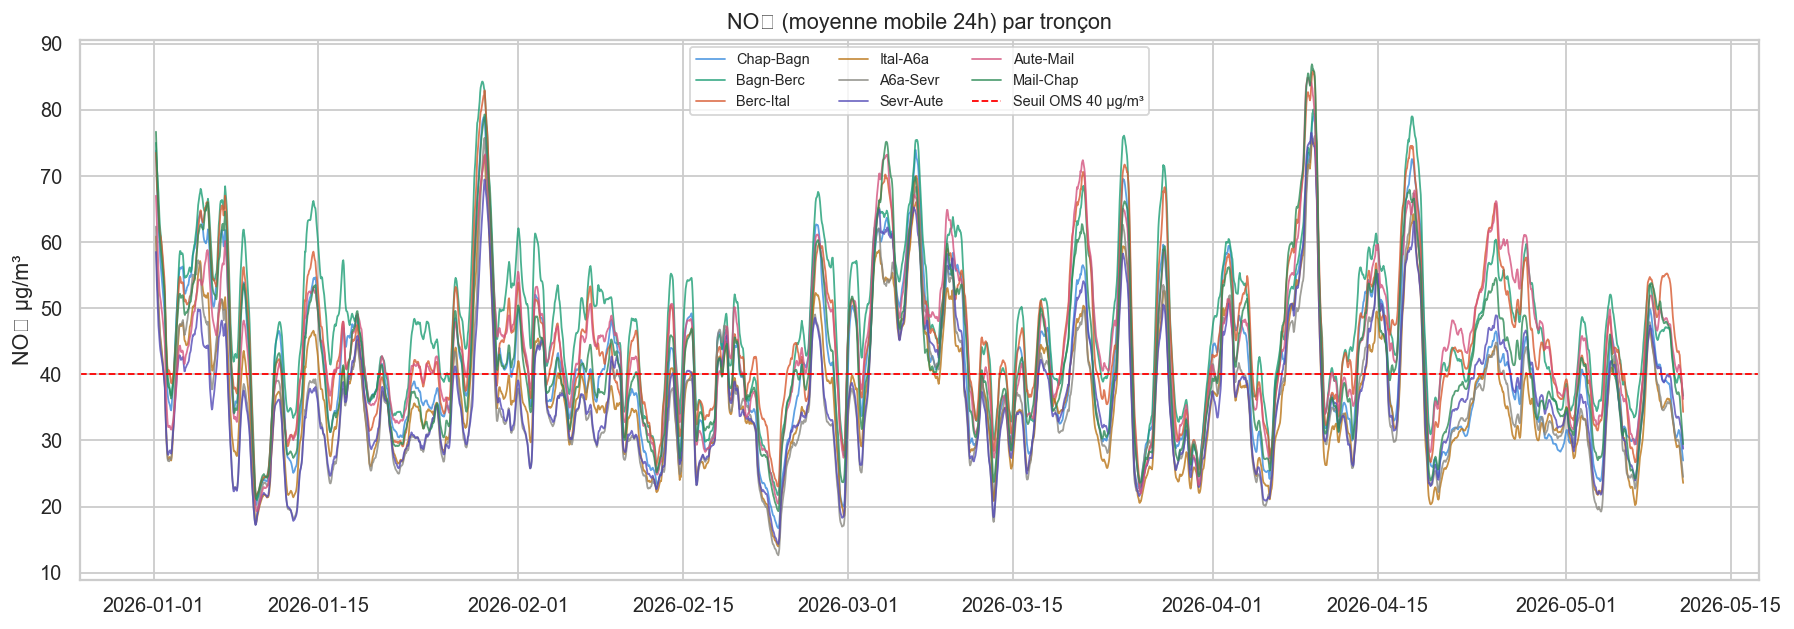

In [9]:
df_sorted = df.sort_values('time').set_index('time')
colors = ['#378ADD','#1D9E75','#D85A30','#BA7517','#888780','#534AB7','#D4537E','#2E8B57']

fig, ax = plt.subplots(figsize=(14, 5))
for col, color in zip(troncons, colors):
    rolling = df_sorted[col].rolling('24h', min_periods=6).mean()
    ax.plot(rolling.index, rolling, label=col, color=color, linewidth=1, alpha=0.8)
ax.axhline(40, color='red', linestyle='--', linewidth=1, label='Seuil OMS 40 µg/m³')
ax.set_title('NO₂ (moyenne mobile 24h) par tronçon')
ax.set_ylabel('NO₂ µg/m³')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

## 8. Profil horaire moyen

/var/folders/qb/k892z_d577q8nhdfb8x4fnrh0000gn/T/ipykernel_13419/2159733315.py:13: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ben/Downloads/developpement_architecture_de_données/projet/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


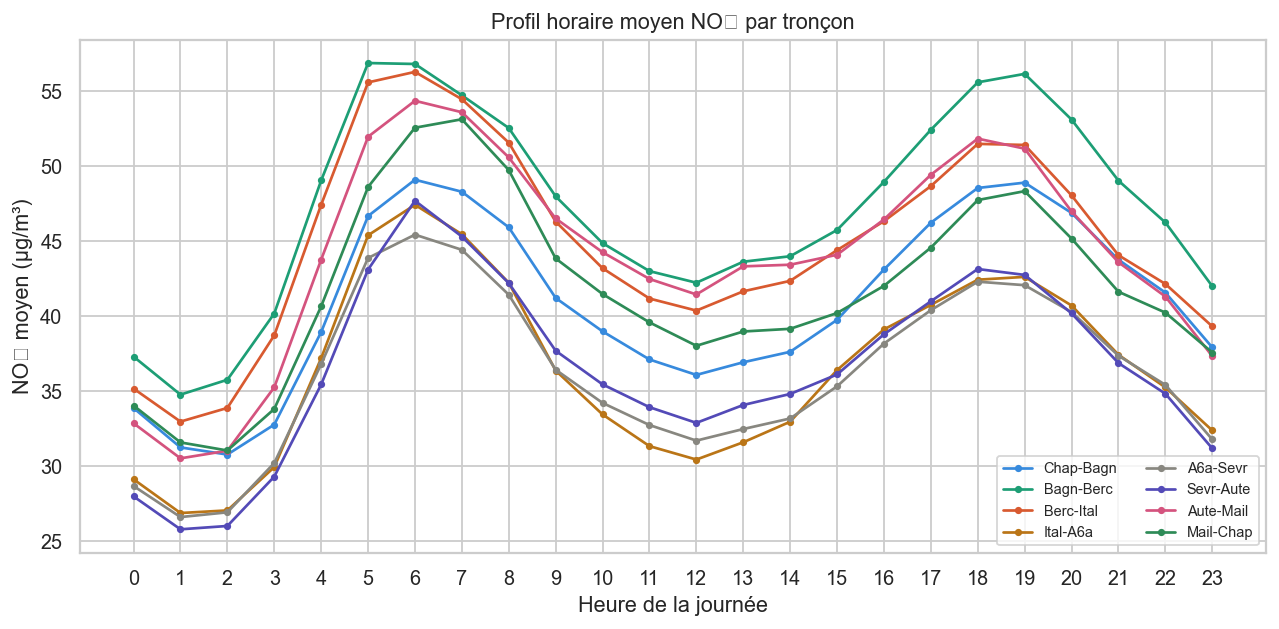

In [10]:
df_h = df_sorted.copy()
df_h['heure'] = df_h.index.hour
hourly = df_h.groupby('heure')[troncons].mean()

fig, ax = plt.subplots(figsize=(10, 5))
for col, color in zip(troncons, colors):
    ax.plot(hourly.index, hourly[col], label=col, color=color, marker='o', markersize=3)
ax.set_title('Profil horaire moyen NO₂ par tronçon')
ax.set_xlabel('Heure de la journée')
ax.set_ylabel('NO₂ moyen (µg/m³)')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 9. Corrélation entre tronçons

/var/folders/qb/k892z_d577q8nhdfb8x4fnrh0000gn/T/ipykernel_13419/1060380156.py:6: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ben/Downloads/developpement_architecture_de_données/projet/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


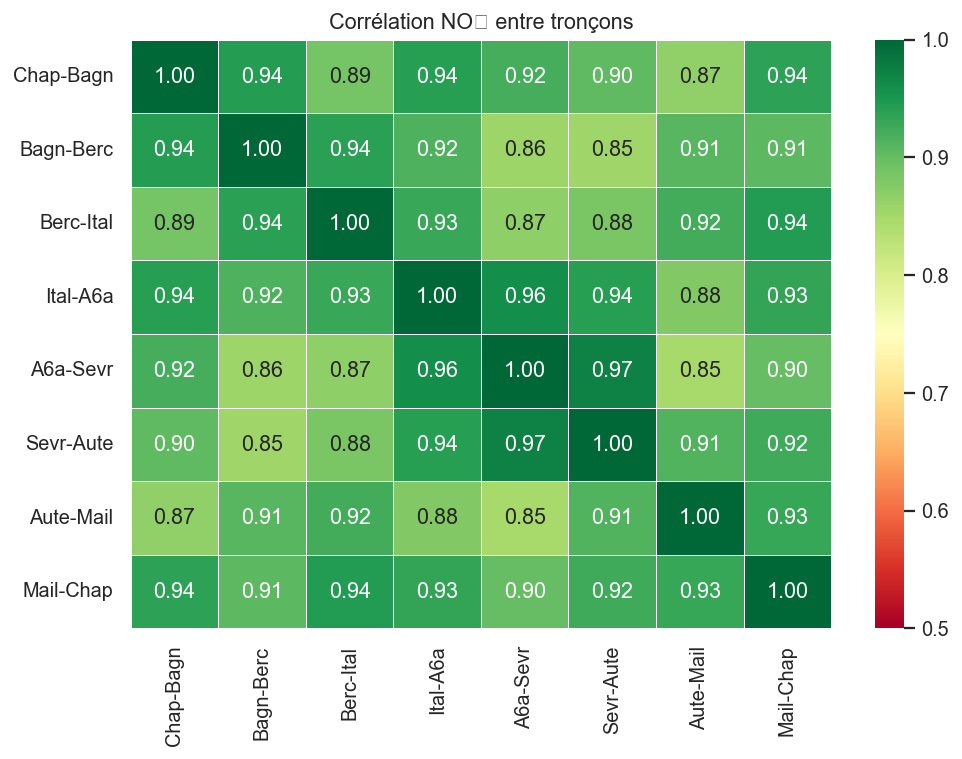

In [11]:
corr = df[troncons].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            vmin=0.5, vmax=1, linewidths=0.5)
ax.set_title('Corrélation NO₂ entre tronçons')
plt.tight_layout()
plt.show()

## 10. Résumé + plan Silver

In [12]:
pct_oms = (df[troncons] > 40).mean().mean() * 100
print('=' * 55)
print('RÉSUMÉ EDA — NO2.csv')
print('=' * 55)
print(f'  Lignes (mesures)     : {len(df):,}')
print(f'  Tronçons             : {len(troncons)}')
print(f'  Couverture           : {df["time"].min()} → {df["time"].max()}')
print(f'  NaN par tronçon      : ~1.1% (très faible)')
print(f'  % mesures > OMS 40   : {pct_oms:.1f}% en moyenne')
print('=' * 55)
print()
print('ACTIONS SILVER REQUISES :')
print('  → Interpoler les ~1.1% NaN (interpolation linéaire temporelle)')
print('  → Calculer moyenne journalière et mensuelle par tronçon')
print('  → Identifier les tronçons chroniquement > seuil OMS')
print('  → Agréger en score NO₂ = moyenne annuelle / 40 µg/m³')
print('  → Export Parquet pour Gold scoring vivabilité')

RÉSUMÉ EDA — NO2.csv
  Lignes (mesures)     : 3,120
  Tronçons             : 8
  Couverture           : 2026-01-01 00:00:00 → 2026-05-10 23:00:00
  NaN par tronçon      : ~1.1% (très faible)
  % mesures > OMS 40   : 44.9% en moyenne

ACTIONS SILVER REQUISES :
  → Interpoler les ~1.1% NaN (interpolation linéaire temporelle)
  → Calculer moyenne journalière et mensuelle par tronçon
  → Identifier les tronçons chroniquement > seuil OMS
  → Agréger en score NO₂ = moyenne annuelle / 40 µg/m³
  → Export Parquet pour Gold scoring vivabilité
